# Optics: Diffraction Pattern Anomaly Classification

Classify nominal and anomalous diffraction profiles using quantum kernel and quantum reservoir classifiers.

## Problem, Variables, and Quantum Advantage Context

**Physics problem.** Flag diffraction measurements that deviate from a calibrated single-slit optical setup.

**Explicit variables.** `intensity_profiles` are sampled diffraction traces, `anomaly_label` marks distorted profiles, and `qkc_pred` contains quantum-kernel anomaly predictions.

**Quantum advantage context.** Quantum kernels provide nonlinear similarity models for scientific quality-control settings where waveform shape, not only peak intensity, determines whether an optical measurement is valid.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if repo_root.name == "real_examples":
    repo_root = repo_root.parents[1]
elif repo_root.name == "notebooks":
    repo_root = repo_root.parent

package_root = repo_root / "src"
if str(package_root) not in sys.path:
    sys.path.insert(0, str(package_root))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

from qml import (
    QuantumGaussianProcessRegressor,
    QuantumKernel,
    QuantumKernelClassifier,
    QuantumKernelPCA,
    QuantumKernelRegressor,
    QuantumOneClassClassifier,
    QuantumReservoirClassifier,
    QuantumReservoirFeatures,
    QuantumReservoirRegressor,
    TrainableQuantumKernelRegressor,
)
from qml.reporting import print_section


## Domain simulator

The notebook generates nominal single-slit Fraunhofer intensity profiles and anomalous profiles with shifted, narrowed, or secondary-lobe distortions.

In [2]:
def single_slit_profile(grid, width, center=0.0):
    beta = width * (grid - center)
    profile = np.sinc(beta / np.pi) ** 2
    return profile / profile.max()

def anomalous_profile(grid, width, shift, mix):
    shifted = single_slit_profile(grid, width * 1.25, center=shift)
    secondary = np.cos(1.9 * grid) ** 2 * single_slit_profile(grid, width * 0.55, center=-0.35 * shift)
    profile = (1.0 - mix) * shifted + mix * secondary
    return profile / profile.max()

rng = np.random.default_rng(851)
grid = np.linspace(-3.0, 3.0, 7)
n_nominal = 24
n_anomaly = 24
nominal_width = rng.uniform(1.55, 1.9, size=n_nominal)
nominal_center = rng.normal(0.0, 0.04, size=n_nominal)
nominal = np.asarray([
    single_slit_profile(grid, width, center)
    for width, center in zip(nominal_width, nominal_center)
])
nominal += rng.normal(0.0, 0.01, size=nominal.shape)

anomaly_width = rng.uniform(1.1, 2.2, size=n_anomaly)
anomaly_shift = rng.uniform(0.35, 0.85, size=n_anomaly) * rng.choice([-1.0, 1.0], size=n_anomaly)
anomaly_mix = rng.uniform(0.45, 0.75, size=n_anomaly)
anomaly = np.asarray([
    anomalous_profile(grid, width, shift, mix)
    for width, shift, mix in zip(anomaly_width, anomaly_shift, anomaly_mix)
])
anomaly += rng.normal(0.0, 0.01, size=anomaly.shape)

intensity_profiles = np.vstack([nominal, anomaly])
anomaly_label = np.r_[np.zeros(n_nominal, dtype=int), np.ones(n_anomaly, dtype=int)]

x_train, x_test, y_train, y_test = train_test_split(
    intensity_profiles, anomaly_label, test_size=0.3, random_state=851, stratify=anomaly_label
)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
x_all = scaler.transform(intensity_profiles)

print_section(
    "Dataset",
    [
        ("Problem", "optical diffraction anomaly classification"),
        ("Nominal profiles", int(n_nominal)),
        ("Anomalous profiles", int(n_anomaly)),
        ("Features", [f"I(theta={g:.1f})" for g in grid]),
        ("Classes", {0: "nominal", 1: "anomalous"}),
    ],
)


Dataset
+--------------------+-------------------------------------------------------------------------------------------------------+
| Metric             | Value                                                                                                 |
+--------------------+-------------------------------------------------------------------------------------------------------+
| Problem            | optical diffraction anomaly classification                                                            |
| Nominal profiles   | 24                                                                                                    |
| Anomalous profiles | 24                                                                                                    |
| Features           | [I(theta=-3.0), I(theta=-2.0), I(theta=-1.0), I(theta=0.0), I(theta=1.0), I(theta=2.0), I(theta=3.0)] |
| Classes            | {0: 'nominal', 1: 'anomalous'}                                                  

## System visualization

A direct plot of the simulated physical or mathematical system before fitting any machine-learning model.

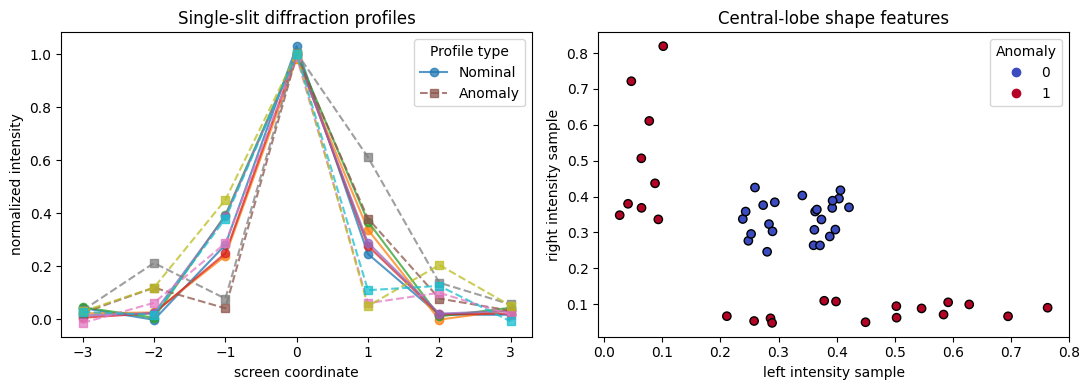

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for idx in range(5):
    axes[0].plot(grid, nominal[idx], "o-", alpha=0.75, label="Nominal" if idx == 0 else None)
for idx in range(5):
    axes[0].plot(grid, anomaly[idx], "s--", alpha=0.75, label="Anomaly" if idx == 0 else None)
axes[0].set_title("Single-slit diffraction profiles")
axes[0].set_xlabel("screen coordinate")
axes[0].set_ylabel("normalized intensity")
axes[0].legend(title="Profile type")
scatter = axes[1].scatter(intensity_profiles[:, 2], intensity_profiles[:, 4], c=anomaly_label, cmap="coolwarm", edgecolor="black")
axes[1].set_title("Central-lobe shape features")
axes[1].set_xlabel("left intensity sample")
axes[1].set_ylabel("right intensity sample")
axes[1].legend(*scatter.legend_elements(), title="Anomaly")
plt.tight_layout()
plt.show()


## Package-client anomaly classifiers

In [4]:
qkc = QuantumKernelClassifier(QuantumKernel(embedding="iqp", seed=851))
qkc.fit(x_train, y_train)
qkc_pred = qkc.predict(x_test)

reservoir = QuantumReservoirClassifier(
    QuantumReservoirFeatures(n_qubits=7, n_layers=2, seed=852),
    c=1.0,
    max_iter=1000,
)
reservoir.fit(x_train, y_train)
reservoir_pred = reservoir.predict(x_test)

logistic = LogisticRegression(max_iter=1000)
logistic.fit(x_train, y_train)
logistic_pred = logistic.predict(x_test)

results = {
    "quantum_kernel_accuracy": accuracy_score(y_test, qkc_pred),
    "quantum_reservoir_accuracy": accuracy_score(y_test, reservoir_pred),
    "logistic_accuracy": accuracy_score(y_test, logistic_pred),
    "quantum_anomaly_recall": float(np.mean(qkc_pred[y_test == 1] == 1)),
}

print_section(
    "Results",
    [
        ("Quantum kernel accuracy", results["quantum_kernel_accuracy"]),
        ("Quantum reservoir accuracy", results["quantum_reservoir_accuracy"]),
        ("Logistic accuracy", results["logistic_accuracy"]),
        ("Quantum anomaly recall", results["quantum_anomaly_recall"]),
    ],
)


Results
+----------------------------+----------+
| Metric                     | Value    |
+----------------------------+----------+
| Quantum kernel accuracy    | 1        |
| Quantum reservoir accuracy | 0.466667 |
| Logistic accuracy          | 1        |
| Quantum anomaly recall     | 1        |
+----------------------------+----------+



## Plots

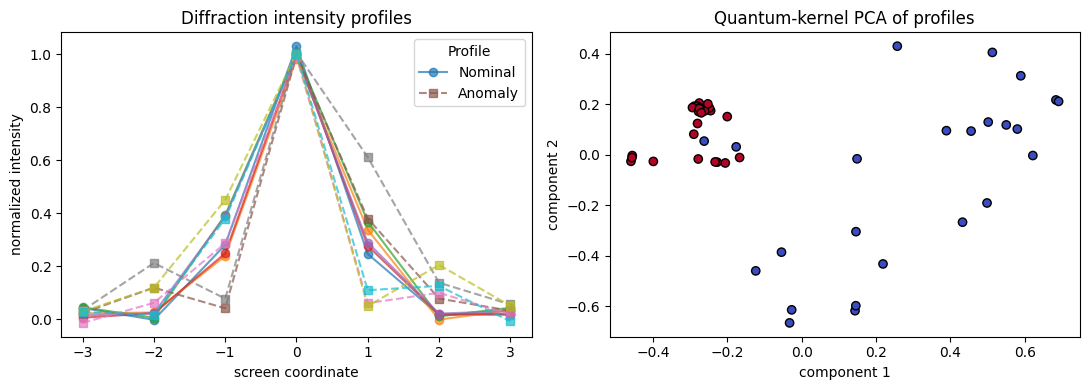

In [5]:
kpca = QuantumKernelPCA(QuantumKernel(embedding="zz", seed=853), n_components=2)
embedding = kpca.fit_transform(x_all)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for idx in range(5):
    axes[0].plot(grid, nominal[idx], "o-", alpha=0.7, label="Nominal" if idx == 0 else None)
for idx in range(5):
    axes[0].plot(grid, anomaly[idx], "s--", alpha=0.7, label="Anomaly" if idx == 0 else None)
axes[0].set_title("Diffraction intensity profiles")
axes[0].set_xlabel("screen coordinate")
axes[0].set_ylabel("normalized intensity")
axes[0].legend(title="Profile")

axes[1].scatter(embedding[:, 0], embedding[:, 1], c=anomaly_label, cmap="coolwarm", edgecolor="black")
axes[1].set_title("Quantum-kernel PCA of profiles")
axes[1].set_xlabel("component 1")
axes[1].set_ylabel("component 2")
plt.tight_layout()
plt.show()


## Validation block

In [6]:
validation = {
    "dataset": {
        "problem": "optical_diffraction_anomaly_classification",
        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),
        "feature_count": int(x_train.shape[1]),
    },
    "results": results,
    "sample_predictions": [
        {"actual_label": int(label), "quantum_kernel_prediction": int(pred), "reservoir_prediction": int(res)}
        for label, pred, res in zip(y_test[:8], qkc_pred[:8], reservoir_pred[:8])
    ],
    "passed": bool(
        np.isfinite(qkc_pred).all()
        and results["quantum_kernel_accuracy"] >= 0.80
        and results["quantum_anomaly_recall"] >= 0.80
    ),
}

print("Validation")
print_section("Dataset", validation["dataset"].items())
print_section("Results", validation["results"].items())
print_section("Sample predictions", validation["sample_predictions"][:5])
print_section("Passed", [("passed", validation["passed"])])


Validation
Dataset
+---------------+--------------------------------------------+
| Metric        | Value                                      |
+---------------+--------------------------------------------+
| problem       | optical_diffraction_anomaly_classification |
| n_train       | 33                                         |
| n_test        | 15                                         |
| feature_count | 7                                          |
+---------------+--------------------------------------------+

Results
+----------------------------+----------+
| Metric                     | Value    |
+----------------------------+----------+
| quantum_kernel_accuracy    | 1        |
| quantum_reservoir_accuracy | 0.466667 |
| logistic_accuracy          | 1        |
| quantum_anomaly_recall     | 1        |
+----------------------------+----------+

Sample predictions
+--------------+---------------------------+----------------------+
| actual_label | quantum_kernel_prediction |